In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training data
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

print("Original Training Data Shape:", train_df.shape)
print("Original Test Data Shape:", test_df.shape)

Original Training Data Shape: (59611, 24)
Original Test Data Shape: (14900, 23)


## Step 1: Handle Age Inconsistencies

We'll remove rows with:
- years_with_startup > founder_age (impossible timeline)
- years_since_founding > founder_age (company founded before founder was born)

In [2]:
# Identify problematic rows
print("="*70)
print("AGE INCONSISTENCY ANALYSIS")
print("="*70)

# Issue 1: years_with_startup > founder_age
issue1_mask = train_df['years_with_startup'] > train_df['founder_age']
issue1_count = issue1_mask.sum()
print(f"\n1. Years with startup > age: {issue1_count} rows")
if issue1_count > 0:
    print("   Sample cases:")
    print(train_df[issue1_mask][['founder_id', 'founder_age', 'years_with_startup']].head())

# Issue 2: years_since_founding > founder_age
issue2_mask = train_df['years_since_founding'] > train_df['founder_age']
issue2_count = issue2_mask.sum()
print(f"\n2. Company founded before founder born: {issue2_count} rows ({issue2_count/len(train_df)*100:.2f}%)")
if issue2_count > 0:
    print("   Sample cases:")
    print(train_df[issue2_mask][['founder_id', 'founder_age', 'years_since_founding']].head())

# Combined mask for all age inconsistencies
age_issues_mask = issue1_mask | issue2_mask
total_age_issues = age_issues_mask.sum()

print(f"\n{'='*70}")
print(f"TOTAL ROWS WITH AGE INCONSISTENCIES: {total_age_issues} ({total_age_issues/len(train_df)*100:.2f}%)")
print(f"{'='*70}")

AGE INCONSISTENCY ANALYSIS

1. Years with startup > age: 3 rows
   Sample cases:
       founder_id  founder_age  years_with_startup
50279       50946           13                  22
51116        4762            6                   9
56103       34398           23                  26

2. Company founded before founder born: 39355 rows (66.02%)
   Sample cases:
   founder_id  founder_age  years_since_founding
0        8410           31                  89.0
2       30257           24                  74.0
3       65791           36                  50.0
4       65026           56                  68.0
5       24368           38                  47.0

TOTAL ROWS WITH AGE INCONSISTENCIES: 39355 (66.02%)


In [3]:
# Remove rows with age inconsistencies
train_df_cleaned = train_df[~age_issues_mask].copy()

print(f"Original training data: {len(train_df)} rows")
print(f"Removed: {len(train_df) - len(train_df_cleaned)} rows")
print(f"Cleaned training data: {len(train_df_cleaned)} rows ({len(train_df_cleaned)/len(train_df)*100:.2f}% retained)")

Original training data: 59611 rows
Removed: 39355 rows
Cleaned training data: 20256 rows (33.98% retained)


## Step 2: Analyze Missing Values

In [4]:
# Check missing values in cleaned data
print("="*70)
print("MISSING VALUES ANALYSIS - AFTER AGE CLEANING")
print("="*70)

missing_summary = train_df_cleaned.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print("\nColumns with missing values:")
    for col, count in missing_summary.items():
        percentage = (count / len(train_df_cleaned)) * 100
        print(f"  {col:30s}: {count:5d} ({percentage:5.2f}%)")
    
    print(f"\nTotal missing values: {missing_summary.sum()}")
else:
    print("\nNo missing values found!")

MISSING VALUES ANALYSIS - AFTER AGE CLEANING

Columns with missing values:
  work_life_balance_rating      :  5884 (29.05%)
  venture_satisfaction          :  5057 (24.97%)
  num_dependents                :  4360 (21.52%)
  years_since_founding          :  4184 (20.66%)
  team_size_category            :  2992 (14.77%)
  monthly_revenue_generated     :  1800 ( 8.89%)

Total missing values: 24277


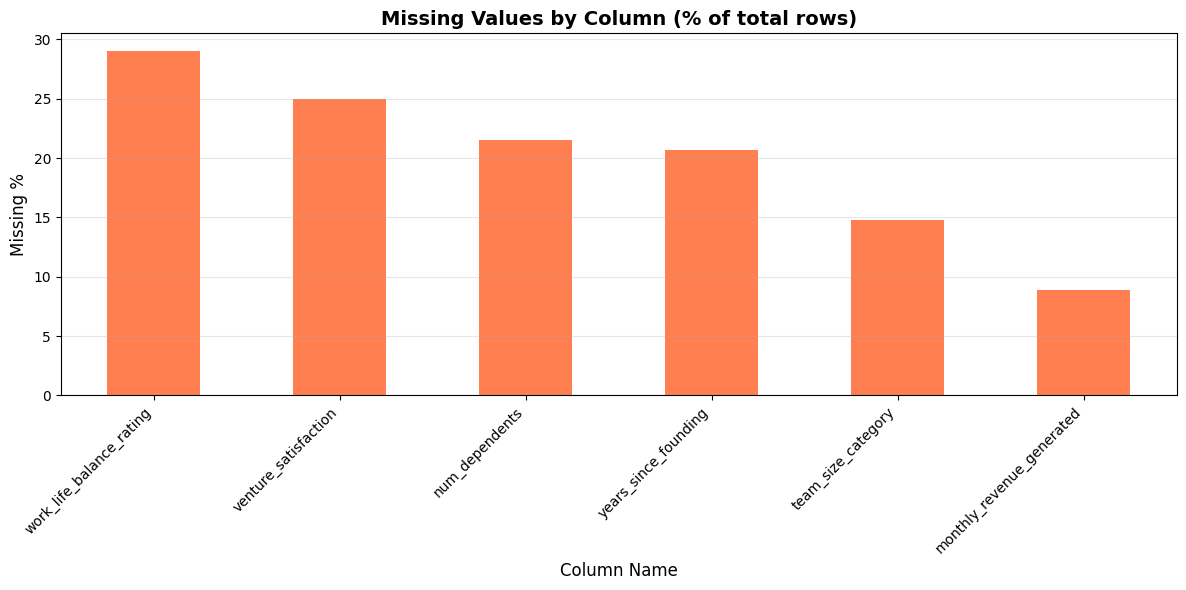

In [5]:
# Visualize missing values
if len(missing_summary) > 0:
    plt.figure(figsize=(12, 6))
    missing_pct = (train_df_cleaned.isnull().sum() / len(train_df_cleaned) * 100)
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
    
    missing_pct.plot(kind='bar', color='coral')
    plt.title('Missing Values by Column (% of total rows)', fontsize=14, fontweight='bold')
    plt.xlabel('Column Name', fontsize=12)
    plt.ylabel('Missing %', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Step 3: Handle Missing Values

Strategy:
- **Numerical features**: Impute with median (robust to outliers)
- **Categorical features**: Impute with mode or create 'Unknown' category
- **Consider**: Drop rows with >50% missing values (if any)

In [6]:
# Check rows with high percentage of missing values
missing_per_row = train_df_cleaned.isnull().sum(axis=1)
high_missing_threshold = len(train_df_cleaned.columns) * 0.5

rows_with_high_missing = (missing_per_row > high_missing_threshold).sum()
print(f"Rows with >50% missing values: {rows_with_high_missing}")

if rows_with_high_missing > 0:
    print(f"Removing {rows_with_high_missing} rows with excessive missing values...")
    train_df_cleaned = train_df_cleaned[missing_per_row <= high_missing_threshold].copy()
    print(f"Remaining rows: {len(train_df_cleaned)}")

Rows with >50% missing values: 0


In [7]:
# Identify column types
numerical_cols = train_df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_df_cleaned.select_dtypes(include=['object']).columns.tolist()

# Remove ID and target column from imputation
if 'founder_id' in numerical_cols:
    numerical_cols.remove('founder_id')
if 'retention_status' in categorical_cols:
    categorical_cols.remove('retention_status')

print(f"Numerical columns to impute: {len(numerical_cols)}")
print(f"Categorical columns to impute: {len(categorical_cols)}")

Numerical columns to impute: 7
Categorical columns to impute: 15


In [8]:
# Handle numerical missing values
print("\nHandling numerical missing values...")
for col in numerical_cols:
    if train_df_cleaned[col].isnull().sum() > 0:
        median_value = train_df_cleaned[col].median()
        missing_count = train_df_cleaned[col].isnull().sum()
        train_df_cleaned[col].fillna(median_value, inplace=True)
        print(f"  {col}: Filled {missing_count} missing values with median = {median_value:.2f}")
        
        # Apply same to test data
        if col in test_df.columns:
            test_missing = test_df[col].isnull().sum()
            if test_missing > 0:
                test_df[col].fillna(median_value, inplace=True)
                print(f"    (Also filled {test_missing} in test data)")


Handling numerical missing values...
  monthly_revenue_generated: Filled 1800 missing values with median = 7371.00
    (Also filled 447 in test data)
  num_dependents: Filled 4360 missing values with median = 1.00
    (Also filled 1192 in test data)
  years_since_founding: Filled 4184 missing values with median = 27.00
    (Also filled 1043 in test data)


/var/folders/w1/h8z88ggs70x5m3kjwhnx8g2r0000gn/T/ipykernel_19621/582336011.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_cleaned[col].fillna(median_value, inplace=True)
/var/folders/w1/h8z88ggs70x5m3kjwhnx8g2r0000gn/T/ipykernel_19621/582336011.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [9]:
# Handle categorical missing values
print("\nHandling categorical missing values...")
for col in categorical_cols:
    if train_df_cleaned[col].isnull().sum() > 0:
        mode_value = train_df_cleaned[col].mode()[0] if len(train_df_cleaned[col].mode()) > 0 else 'Unknown'
        missing_count = train_df_cleaned[col].isnull().sum()
        train_df_cleaned[col].fillna(mode_value, inplace=True)
        print(f"  {col}: Filled {missing_count} missing values with mode = '{mode_value}'")
        
        # Apply same to test data
        if col in test_df.columns:
            test_missing = test_df[col].isnull().sum()
            if test_missing > 0:
                test_df[col].fillna(mode_value, inplace=True)
                print(f"    (Also filled {test_missing} in test data)")


Handling categorical missing values...
  work_life_balance_rating: Filled 5884 missing values with mode = 'Good'
    (Also filled 2533 in test data)
  venture_satisfaction: Filled 5057 missing values with mode = 'High'
    (Also filled 1788 in test data)
  team_size_category: Filled 2992 missing values with mode = 'Medium'
    (Also filled 745 in test data)


/var/folders/w1/h8z88ggs70x5m3kjwhnx8g2r0000gn/T/ipykernel_19621/2652269971.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_cleaned[col].fillna(mode_value, inplace=True)
/var/folders/w1/h8z88ggs70x5m3kjwhnx8g2r0000gn/T/ipykernel_19621/2652269971.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

In [10]:
# Verify no missing values remain
print("\n" + "="*70)
print("VERIFICATION - MISSING VALUES AFTER CLEANING")
print("="*70)

remaining_missing_train = train_df_cleaned.isnull().sum().sum()
remaining_missing_test = test_df.isnull().sum().sum()

print(f"\nTraining data missing values: {remaining_missing_train}")
print(f"Test data missing values: {remaining_missing_test}")

if remaining_missing_train == 0 and remaining_missing_test == 0:
    print("\n✓ SUCCESS: All missing values have been handled!")
else:
    print("\n⚠ WARNING: Some missing values remain")
    if remaining_missing_train > 0:
        print("\nRemaining in training data:")
        print(train_df_cleaned.isnull().sum()[train_df_cleaned.isnull().sum() > 0])
    if remaining_missing_test > 0:
        print("\nRemaining in test data:")
        print(test_df.isnull().sum()[test_df.isnull().sum() > 0])


VERIFICATION - MISSING VALUES AFTER CLEANING

Training data missing values: 0
Test data missing values: 0

✓ SUCCESS: All missing values have been handled!


## Step 4: Save Cleaned Data

In [11]:
# Save cleaned datasets
train_df_cleaned.to_csv('dataset/train_cleaned.csv', index=False)
test_df.to_csv('dataset/test_cleaned.csv', index=False)

print("="*70)
print("CLEANING SUMMARY")
print("="*70)
print(f"\nOriginal training data: {len(train_df)} rows, {len(train_df.columns)} columns")
print(f"Cleaned training data:  {len(train_df_cleaned)} rows, {len(train_df_cleaned.columns)} columns")
print(f"Rows removed:           {len(train_df) - len(train_df_cleaned)} ({(len(train_df) - len(train_df_cleaned))/len(train_df)*100:.2f}%)")
print(f"\nTest data:              {len(test_df)} rows (no rows removed, only imputation applied)")
print(f"\nFiles saved:")
print(f"  - dataset/train_cleaned.csv")
print(f"  - dataset/test_cleaned.csv")

CLEANING SUMMARY

Original training data: 59611 rows, 24 columns
Cleaned training data:  20256 rows, 24 columns
Rows removed:           39355 (66.02%)

Test data:              14900 rows (no rows removed, only imputation applied)

Files saved:
  - dataset/train_cleaned.csv
  - dataset/test_cleaned.csv


## Step 5: Compare Distributions Before/After Cleaning

In [12]:
# Compare target variable distribution
print("\nTarget Variable Distribution Comparison:")
print("\nOriginal:")
print(train_df['retention_status'].value_counts(normalize=True))
print("\nCleaned:")
print(train_df_cleaned['retention_status'].value_counts(normalize=True))


Target Variable Distribution Comparison:

Original:
retention_status
Stayed    0.524484
Left      0.475516
Name: proportion, dtype: float64

Cleaned:
retention_status
Stayed    0.519155
Left      0.480845
Name: proportion, dtype: float64


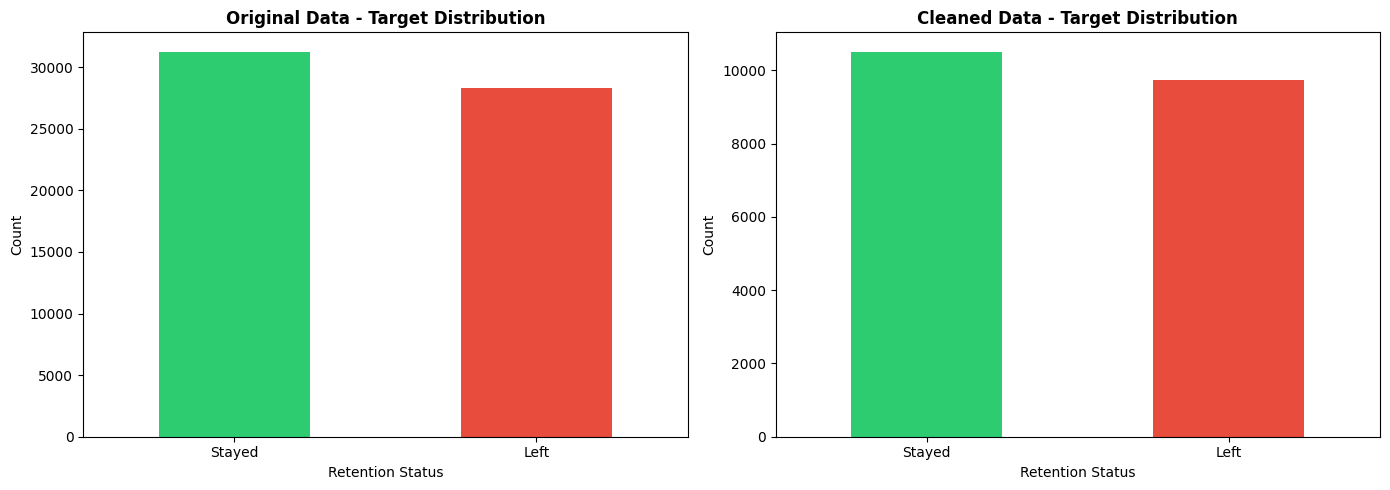


✓ Data cleaning completed successfully!


In [13]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
train_df['retention_status'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Original Data - Target Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Retention Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Cleaned
train_df_cleaned['retention_status'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Cleaned Data - Target Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Retention Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n✓ Data cleaning completed successfully!")